In [93]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import json

In [94]:
# ls ../../

In [95]:
# Gather all the text files for Essays
essay_folder = "../../data/eval/texts/test_essay/"
essay_files = [f for f in os.listdir(essay_folder) if f.endswith(".txt")]
essay_dict = {}

for file in essay_files:
    file_path = os.path.join(essay_folder, file)
    with open(file_path, "r", encoding="utf-8") as f:
        content = f.read()
        essay_dict[file] = content

essay_dict

{'Article_C2_Profishency_Response_3.txt': '‘An Unforgettable Event’\nI remember it as if it was yesterday that when my English teacher came to me during \na school break and asked me: ‘how would you like to go to Canda Canada for a month \nto study at a local highschoo high school, all expenses paid?’ As you can imagine, my jaw \ndropped something like ten feet at the mere thought of it. I was sixteen at the time \nand it seemed like the world was opening in front of me. After I recovered from the \nimmediate schock I said I would go in a heartbeat, and so we went into the Principle’s \noffice to call my mother. It wasn’t me making the phonecall but I could persf perfectly \nimagine what my mom’s face was at the other end of the line. Firt of all, she would be \ncompletely puzzled that I was at the Principal’s office because I never got into trouble. \nSecond After that, I imagine she was in utter disbelief when she heard the \nwords: ‘your daughter is going to Canada for a month, if t

In [96]:
fiction_folder = "../../data/eval/texts/test_fiction/"
fiction_files = [f for f in os.listdir(fiction_folder) if f.endswith(".txt")]
fiction_dict = {}

for file in fiction_files:
    file_path = os.path.join(fiction_folder, file)
    with open(file_path, "r", encoding="utf-8") as f:
        content = f.read()
        fiction_dict[file] = content
fiction_dict

{'LotR_Chapter_1_1_500.txt': 'Chapter 1\n\nA LONG-EXPECTED PARTY\n\nWhen Mr. Bilbo Baggins of Bag End announced that he\nwould shortly be celebrating his eleventy-ﬁrst birthday with\na party of special magniﬁcence, there was much talk and\nexcitement in Hobbiton.\nBilbo was very rich and very peculiar, and had been the\nwonder of the Shire for sixty years, ever since his remarkable\ndisappearance and unexpected return. The riches he had\nbrought back from his travels had now become a local legend,\nand it was popularly believed, whatever the old folk might\nsay, that the Hill at Bag End was full of tunnels stuffed with\ntreasure. And if that was not enough for fame, there was also\nhis prolonged vigour to marvel at. Time wore on, but it\nseemed to have little effect on Mr. Baggins. At ninety he was\nmuch the same as at ﬁfty. At ninety-nine they began to call\nhim well-preserved; but unchanged would have been nearer the\nmark. There were some that shook their heads and thought\nthis was

In [97]:
# Temporary to remove some items from the essay_dict for testing
test_dict = {essay_dict.popitem(), essay_dict.popitem(), essay_dict.popitem(), essay_dict.popitem(), essay_dict.popitem(), essay_dict.popitem(), essay_dict.popitem()}
test_dict

{('Essay_C2_Profishency_Response_2.txt',
  ' First text suggest that nowadays the population is experiencing the new \ninnovations and technologies with extremely fast tempo. This process has a massive \nimpact on both: older and younger generations. Youngsters cope with the new \ntechnologies in different way in comparison to eldery people. They adapt new things \nrather quiet easily, because they do get used to things rather quickly. Often, older \npeople require more time to accept changes in order to start feeling comfortable \naround with them. Our respond and positive attitude is crucial if we are willing to \nprogress and make changes for a future generations. If the society opens up for the \nnew innovations we are going to face a bright future in front of us. Exploring things \nis the key to success.\n Second text on the other hand suggest that society should not feel rushed \nto use new technologies as every human being needs a decent amount of time for \nthe esen essential p

In [98]:
sns.set_theme(style="whitegrid", palette="muted")

data = []
file_path = "../../reports/eval_generation_essay_results.jsonl" 

try:
    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            data.append(json.loads(line.strip()))
except FileNotFoundError:
    print(f"Could not find the file at: {file_path}")

df_essay = pd.DataFrame(data)

df_essay.head()

,timestamp,file_name,eval_type,embedding_model,llm_model,judge_model,temperature,chunk_size,chunk_overlap,top_k,device_name,ram_gb,duration_seconds,average_score,per_test
0,2026-04-21T11:07:47.732964,Essay_C2_Profishency_Response_1.txt,generation,nomic-embed-text,mistral,llama3.1:8b,0.1,1000,200,3,SIS-Notebook,33.5,351.80,0.7667,"[{'metric': 'grammar', 'score': 0.7, 'reason':..."
1,2026-04-21T11:15:02.368019,Essay_C2_Profishency_Response_2.txt,generation,nomic-embed-text,mistral,llama3.1:8b,0.1,1000,200,3,SIS-Notebook,33.5,184.41,0.8000,"[{'metric': 'grammar', 'score': 1.0, 'reason':..."
2,2026-04-21T11:24:49.314844,Review_C2_Profishency_Response_5.txt,generation,nomic-embed-text,mistral,llama3.1:8b,0.1,1000,200,3,SIS-Notebook,33.5,243.37,0.6667,"[{'metric': 'grammar', 'score': 0.7, 'reason':..."
3,2026-04-21T13:46:53.894081,Article_C2_Profishency_Response_3.txt,generation,nomic-embed-text,llama3.1,llama3.1:8b,0.1,1000,200,3,SIS-Notebook,33.5,395.61,0.6667,"[{'metric': 'grammar', 'score': 0.6, 'reason':..."
4,2026-04-21T13:55:51.222106,Essay_C2_Profishency_Response_1.txt,generation,nomic-embed-text,llama3.1,llama3.1:8b,0.1,1000,200,3,SIS-Notebook,33.5,254.27,0.8333,"[{'metric': 'grammar', 'score': 1.0, 'reason':..."


In [99]:
print(f"Loaded {len(df_essay)} total evaluation runs.")
display_cols = ['llm_model', 'file_name', 'average_score', 'duration_seconds', 'ram_gb', 'temperature']

display(df_essay[display_cols].sort_values(by=['average_score', 'temperature'], ascending=[False, True]))

# Mistral is only 7b. Has quick responses and good quality. 
# Best results generally with temperature 0.1, but 0.0 is extremely stable

Loaded 225 total evaluation runs.


,llm_model,file_name,average_score,duration_seconds,ram_gb,temperature
196,qwen3.6:27b,Article_C2_Profishency_Response_3.txt,0.9333,351.75,33.5,0.1
214,gpt-5-nano,Wider_Audience_B1.txt,0.8667,148.20,33.5,0.0
220,gpt-5-nano,Wider_Audience_A1.txt,0.8667,122.04,33.5,0.1
216,gpt-5-nano,Wider_Audience_C1.txt,0.8333,130.70,33.5,0.0
4,llama3.1,Essay_C2_Profishency_Response_1.txt,0.8333,254.27,33.5,0.1
...,...,...,...,...,...,...
18,mistral,Essay_C2_Profishency_Response_2.txt,0.4000,183.44,33.5,0.1
36,minstral-nemo:12b,Essay_C2_Profishency_Response_2.txt,0.4000,182.16,33.5,0.1
72,qwen3:14b,Essay_C2_Profishency_Response_2.txt,0.4000,152.59,33.5,0.1
81,mistral-small3.2:24b,Essay_C2_Profishency_Response_2.txt,0.4000,159.07,33.5,0.1


In [100]:
print(f"Loaded {len(df_essay)} total evaluation runs.")
display_cols = ['llm_model','duration_seconds', 'temperature', 'average_score']

df_summed = (
    df_essay[display_cols]
    .groupby(['llm_model', 'temperature'], as_index=False)
    .mean()
    .sort_values(by=['average_score', 'duration_seconds'], ascending=[False, True])
)

display(df_summed)
# Now we have multiple quick models, with only 8b with good quality.
# In this case Temperature 0.0 is better for the weaker models. Only sufficiently strong models benefit from higher temeprature
# since most feedback is built from a high quality context.


Loaded 225 total evaluation runs.


,llm_model,temperature,duration_seconds,average_score
21,qwen3.6:27b,0.1,263.382222,0.755544
2,gpt-5-nano,0.0,205.701111,0.733344
0,gpt-5-mini,0.0,317.710000,0.733300
3,gpt-5-nano,0.1,175.676667,0.725933
12,mistral-small3.2:24b,0.0,149.360000,0.722233
24,qwen3:8b,0.0,149.470000,0.722233
14,qwen2.5:14b,0.0,150.301111,0.722233
16,qwen2.5:7b,0.0,152.144444,0.722233
22,qwen3:14b,0.0,152.426667,0.722233
8,minstral-nemo:12b,0.0,157.033333,0.722233


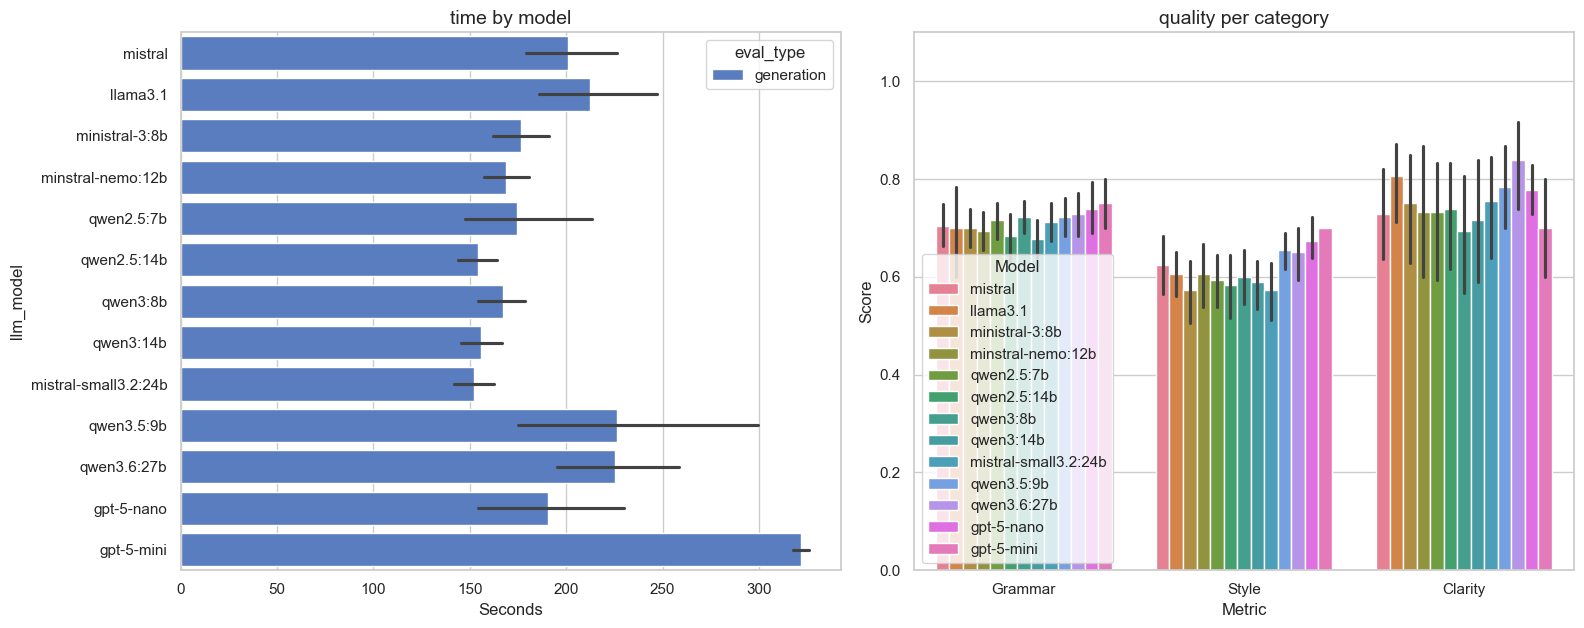

In [101]:
# Plot over all results
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(2, 2)

ax_bl = fig.add_subplot(gs[1, 0])
sns.barplot(data=df_essay, x='duration_seconds', y='llm_model', hue='eval_type', orient='h', ax=ax_bl)
ax_bl.set_title('time by model', fontsize=14)
ax_bl.set_xlabel('Seconds')

ax_br = fig.add_subplot(gs[1, 1])
if not df_essay.empty:
    gen_metrics = []
    for _, row in df_essay.iterrows():
        for test in row['per_test']:
            gen_metrics.append({'Model': row['llm_model'], 'Metric': test['metric'].capitalize(), 'Score': test['score']})
    
    sns.barplot(data=pd.DataFrame(gen_metrics), x='Metric', y='Score', hue='Model', ax=ax_br)
    ax_br.set_title('quality per category', fontsize=14)
    ax_br.set_ylim(0, 1.1)

plt.tight_layout()
plt.show()

In [102]:
# Temperature Split
df_t0 = df_essay[df_essay['temperature'] == 0.0].copy()
df_t01 = df_essay[df_essay['temperature'] == 0.1].copy()

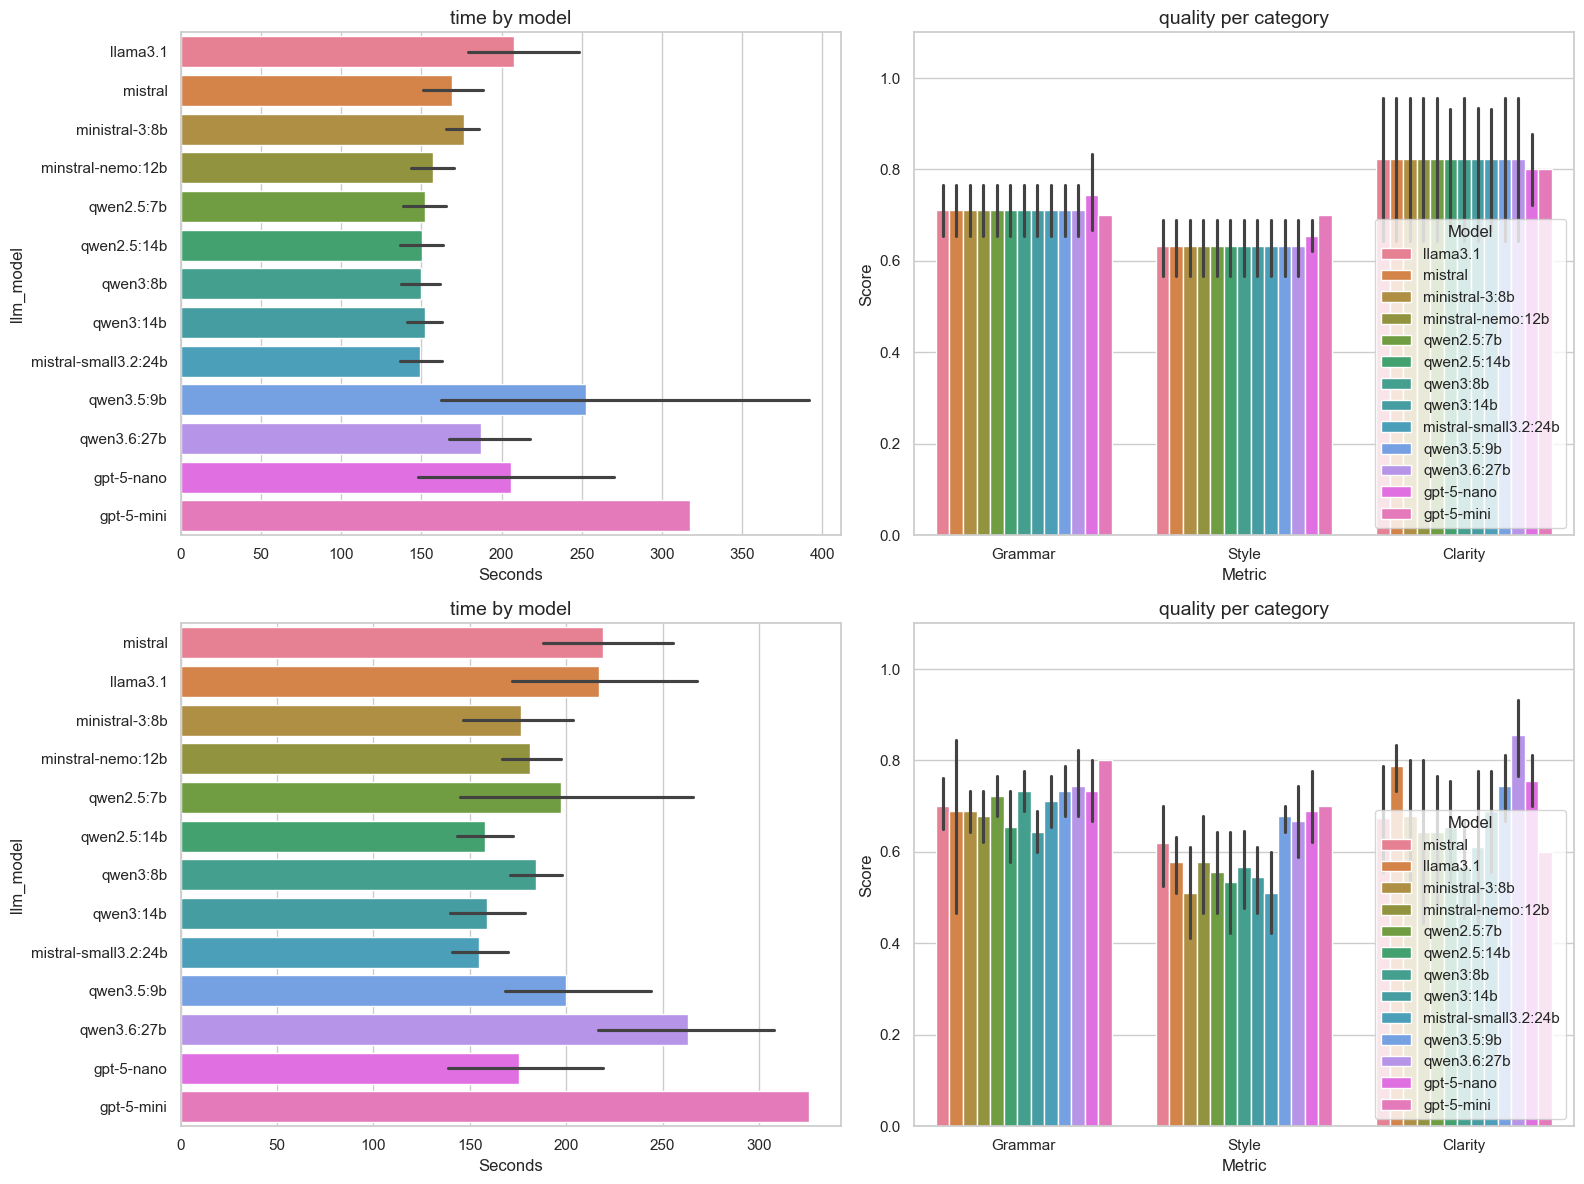

In [103]:
# Temperature Comparison
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(2, 2)

# Temperature 0.0
ax_bl = fig.add_subplot(gs[0, 0])
sns.barplot(data=df_t0, x='duration_seconds', y='llm_model', hue='llm_model', orient='h', ax=ax_bl)
ax_bl.set_title('time by model', fontsize=14)
ax_bl.set_xlabel('Seconds')

ax_br = fig.add_subplot(gs[0, 1])
if not df_t0.empty:
    gen_metrics = []
    for _, row in df_t0.iterrows():
        for test in row['per_test']:
            gen_metrics.append({'Model': row['llm_model'], 'Metric': test['metric'].capitalize(), 'Score': test['score']})
    
    sns.barplot(data=pd.DataFrame(gen_metrics), x='Metric', y='Score', hue='Model', ax=ax_br)
    ax_br.set_title('quality per category', fontsize=14)
    ax_br.set_ylim(0, 1.1)
    
    
# Temperature 0.1
ax_bl = fig.add_subplot(gs[1, 0])
sns.barplot(data=df_t01, x='duration_seconds', y='llm_model', hue='llm_model', orient='h', ax=ax_bl)
ax_bl.set_title('time by model', fontsize=14)
ax_bl.set_xlabel('Seconds')

ax_br = fig.add_subplot(gs[1, 1])
if not df_t01.empty:
    gen_metrics = []
    for _, row in df_t01.iterrows():
        for test in row['per_test']:
            gen_metrics.append({'Model': row['llm_model'], 'Metric': test['metric'].capitalize(), 'Score': test['score']})
    
    sns.barplot(data=pd.DataFrame(gen_metrics), x='Metric', y='Score', hue='Model', ax=ax_br)
    ax_br.set_title('quality per category', fontsize=14)
    ax_br.set_ylim(0, 1.1)

plt.tight_layout()
plt.show()

In [104]:
# Evaluation per Test File Average over those
df_essay.head(2)

,timestamp,file_name,eval_type,embedding_model,llm_model,judge_model,temperature,chunk_size,chunk_overlap,top_k,device_name,ram_gb,duration_seconds,average_score,per_test
0,2026-04-21T11:07:47.732964,Essay_C2_Profishency_Response_1.txt,generation,nomic-embed-text,mistral,llama3.1:8b,0.1,1000,200,3,SIS-Notebook,33.5,351.80,0.7667,"[{'metric': 'grammar', 'score': 0.7, 'reason':..."
1,2026-04-21T11:15:02.368019,Essay_C2_Profishency_Response_2.txt,generation,nomic-embed-text,mistral,llama3.1:8b,0.1,1000,200,3,SIS-Notebook,33.5,184.41,0.8000,"[{'metric': 'grammar', 'score': 1.0, 'reason':..."


In [105]:
essays =["Essay_C2_Profishency_Response_1.txt", "Essay_C2_Profishency_Response_2.txt"]

df_essay_only = df_essay[df_essay['file_name'].isin(essays)]
# df_essay_only.head()

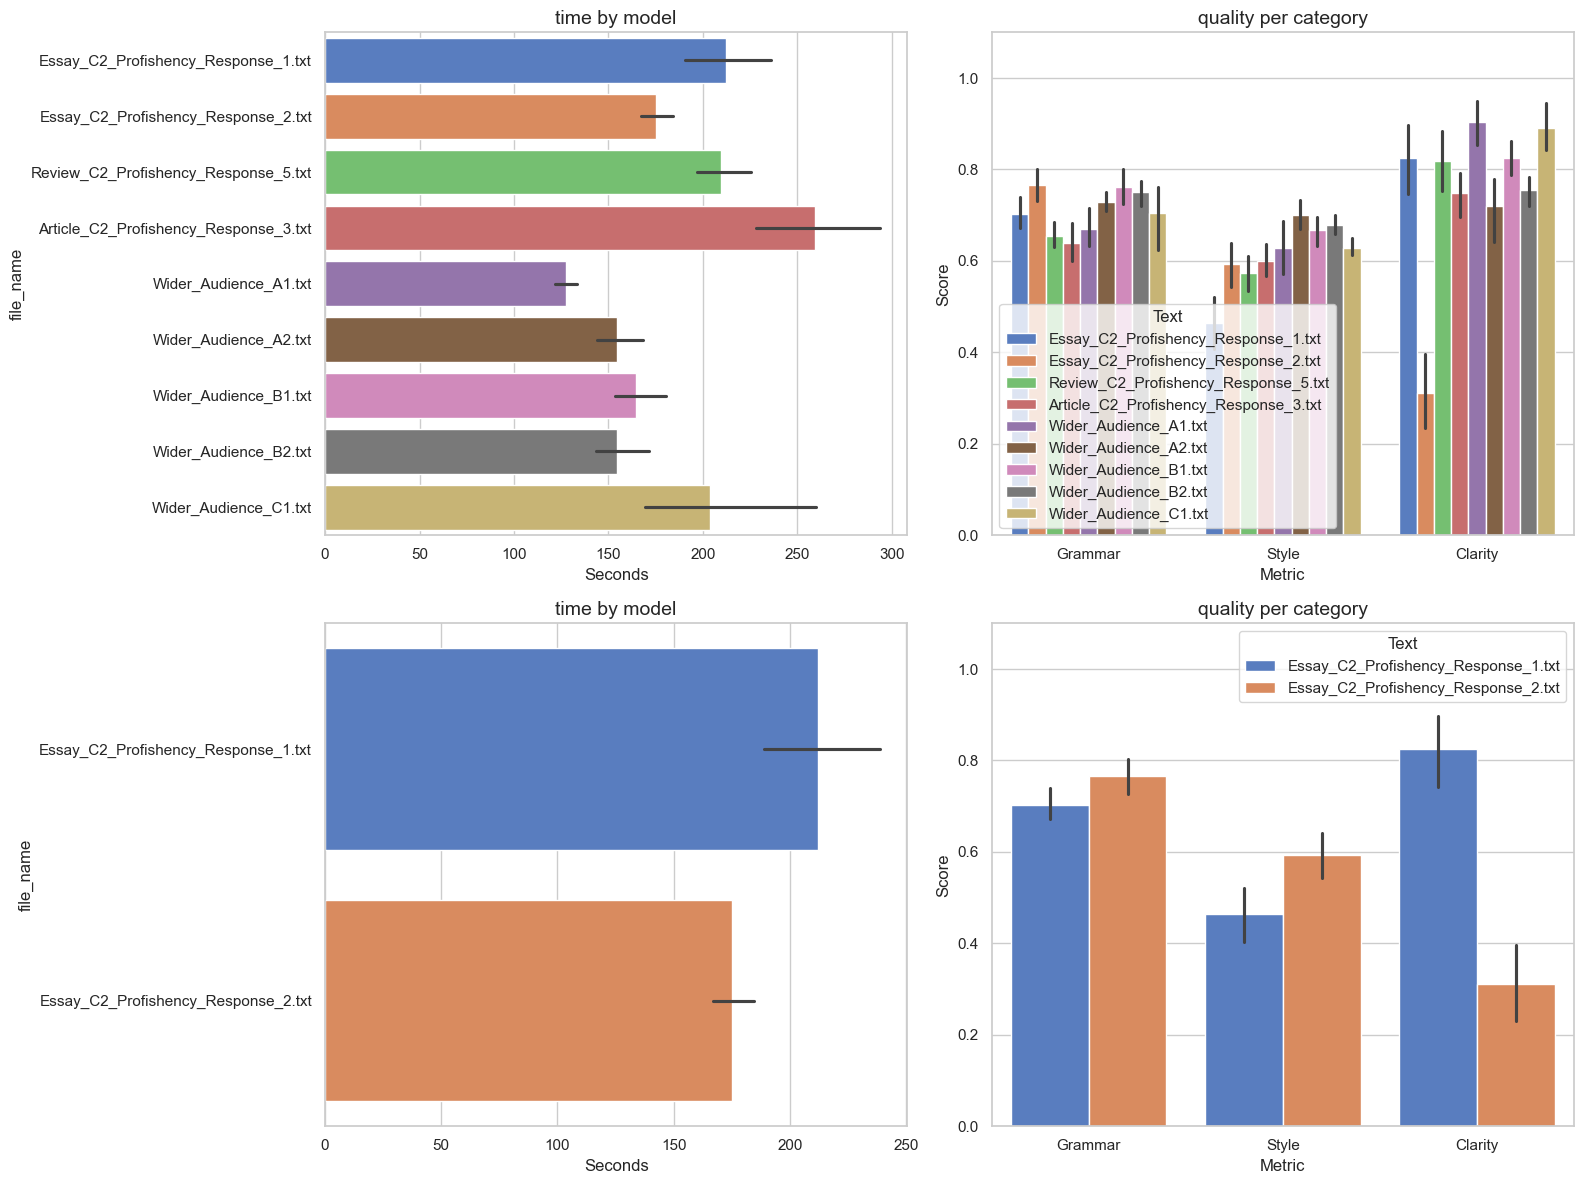

In [106]:
# Plot over all results
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(2, 2)

ax_bl = fig.add_subplot(gs[0, 0])
sns.barplot(data=df_essay, x='duration_seconds', y='file_name', hue='file_name', orient='h', ax=ax_bl)
ax_bl.set_title('time by model', fontsize=14)
ax_bl.set_xlabel('Seconds')

ax_br = fig.add_subplot(gs[0, 1])
if not df_essay.empty:
    gen_metrics = []
    for _, row in df_essay.iterrows():
        for test in row['per_test']:
            gen_metrics.append({'Text': row['file_name'], 'Metric': test['metric'].capitalize(), 'Score': test['score']})
    
    sns.barplot(data=pd.DataFrame(gen_metrics), x='Metric', y='Score', hue='Text', ax=ax_br)
    ax_br.set_title('quality per category', fontsize=14)
    ax_br.set_ylim(0, 1.1)


ax_bl = fig.add_subplot(gs[1, 0])
sns.barplot(data=df_essay_only, x='duration_seconds', y='file_name', hue='file_name', orient='h', ax=ax_bl)
ax_bl.set_title('time by model', fontsize=14)
ax_bl.set_xlabel('Seconds')

ax_br = fig.add_subplot(gs[1, 1])
if not df_essay_only.empty:
    gen_metrics = []
    for _, row in df_essay_only.iterrows():
        for test in row['per_test']:
            gen_metrics.append({'Text': row['file_name'], 'Metric': test['metric'].capitalize(), 'Score': test['score']})
    
    sns.barplot(data=pd.DataFrame(gen_metrics), x='Metric', y='Score', hue='Text', ax=ax_br)
    ax_br.set_title('quality per category', fontsize=14)
    ax_br.set_ylim(0, 1.1)

plt.tight_layout()
plt.show()

In [ ]:
# Evaluation for Fiction
# Both temps needed

In [108]:
sns.set_theme(style="whitegrid", palette="muted")

data = []
file_path = "../../reports/eval_generation_fiction_results.jsonl" 

try:
    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            data.append(json.loads(line.strip()))
except FileNotFoundError:
    print(f"Could not find the file at: {file_path}")

df_fiction = pd.DataFrame(data)

df_fiction.head()

# First two are duds. The Evaluation models context was overwhelmed. 4k words. Plus 6 Responses and the context.
# Redid with "qwen3.6:27b" in metrics_generation

,timestamp,file_name,eval_type,embedding_model,llm_model,judge_model,temperature,chunk_size,chunk_overlap,top_k,device_name,ram_gb,duration_seconds,average_score,per_test
0,2026-04-27T21:04:45.581274,LotR_Chapter_1.txt,generation,nomic-embed-text,llama3.1,llama3.1:8b,0.0,1000,200,3,SIS-Notebook,33.5,1177.66,0.0,"[{'metric': 'grammar', 'score': 0.0, 'reason':..."
1,2026-04-27T22:25:57.834293,LotR_Chapter_1.txt,generation,nomic-embed-text,mistral-small3.2:24b,llama3.1:8b,0.0,1000,200,3,SIS-Notebook,33.5,940.68,0.0,"[{'metric': 'grammar', 'score': 0.0, 'reason':..."


In [109]:
# Split LotR into 4 parts.
# 500, 1000, 2000, 4000 words.  -> Measure the difference in calculation time
# Temperature 0, and 0.1

# First test is with 4000 words. Extremely slow. Since it's 2 * 3 calls of 2000 words.


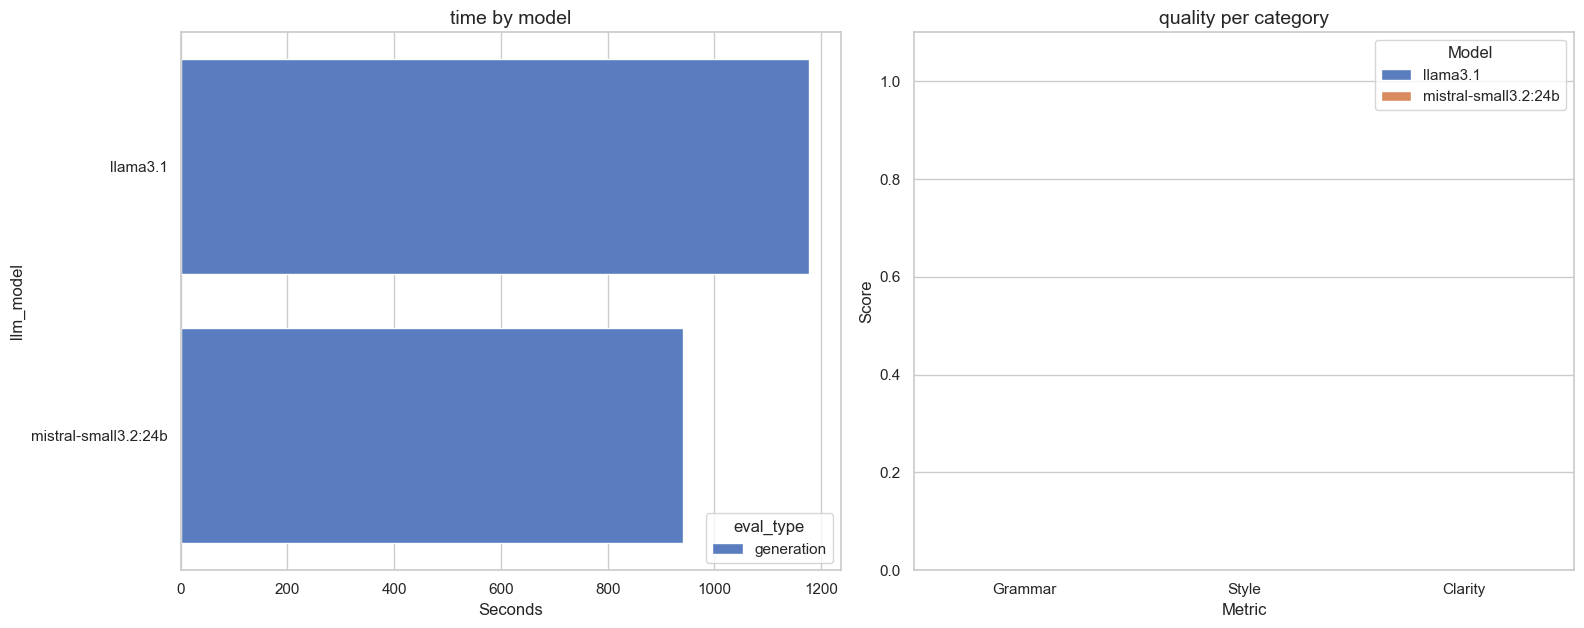

In [110]:
# Plot over all results
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(2, 2)

ax_bl = fig.add_subplot(gs[1, 0])
sns.barplot(data=df_fiction, x='duration_seconds', y='llm_model', hue='eval_type', orient='h', ax=ax_bl)
ax_bl.set_title('time by model', fontsize=14)
ax_bl.set_xlabel('Seconds')

ax_br = fig.add_subplot(gs[1, 1])
if not df_fiction.empty:
    gen_metrics = []
    for _, row in df_fiction.iterrows():
        for test in row['per_test']:
            gen_metrics.append({'Model': row['llm_model'], 'Metric': test['metric'].capitalize(), 'Score': test['score']})
    
    sns.barplot(data=pd.DataFrame(gen_metrics), x='Metric', y='Score', hue='Model', ax=ax_br)
    ax_br.set_title('quality per category', fontsize=14)
    ax_br.set_ylim(0, 1.1)

plt.tight_layout()
plt.show()